#Importo le dipendenze

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers

tf.keras.utils.set_random_seed(42)

#Dataset

##Importo il dataset

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


##Data preparation

In [3]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# check shape
print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [4]:
num_classes = 10
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

print(y_train.shape)
print(y_train[0])

(60000, 10)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


#Modello 1

In [5]:
input_shape = (28,28,1)

model_1 = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(8, kernel_size=3, activation="relu"),
    layers.MaxPool2D(pool_size=3),
    layers.Conv2D(16, kernel_size=3, activation="relu"),
    layers.MaxPool2D(pool_size=3),
    layers.Flatten(),
    layers.Dense(num_classes, activation="softmax")
])

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 6, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 2, 2, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,898 (7.41 KB)

 Trainable params: 1,898 (7.41 KB)

 Non-trainable params: 0 (0.00 B)

##Training

In [6]:
batch_size = 128
epochs = 20

model_1.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history = model_1.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7200 - loss: 0.9922 - val_accuracy: 0.9118 - val_loss: 0.3014
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9213 - loss: 0.2596 - val_accuracy: 0.9417 - val_loss: 0.1940
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9407 - loss: 0.1894 - val_accuracy: 0.9510 - val_loss: 0.1580
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9504 - loss: 0.1589 - val_accuracy: 0.9567 - val_loss: 0.1393
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9561 - loss: 0.1405 - val_accuracy: 0.9610 - val_loss: 0.1272
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9600 - loss: 0.1277 - val_accuracy: 0.9632 - val_loss: 0.1186
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9628 - loss: 0.1181 - val_accuracy: 0.9657 - val_loss: 0.1117
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9651 - loss: 0.1106 - val_accuracy: 0.

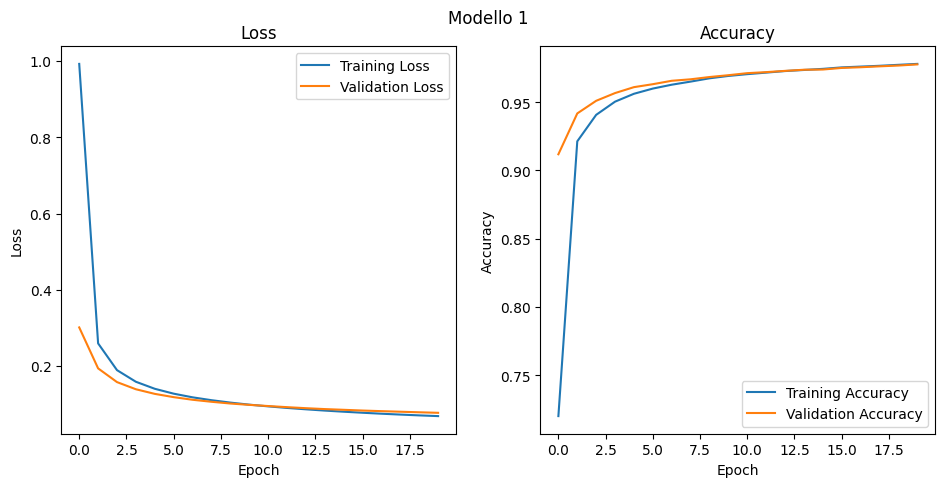

In [7]:
import matplotlib.pyplot as plt
def plot_performance(history, title):
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  fig.tight_layout(pad=3.0)
  plt.suptitle(title)
  train_acc = history.history['accuracy']
  valid_acc = history.history['val_accuracy']
  train_loss = history.history['loss']
  valid_loss = history.history['val_loss']
  ax[0].set_xlabel('Epoch')
  ax[0].set_ylabel('Loss')
  ax[0].set_title('Loss')
  ax[0].plot(train_loss, label='Training Loss')
  ax[0].plot(valid_loss, label='Validation Loss')
  ax[0].legend()
  ax[1].set_title('Accuracy')
  ax[1].set_xlabel('Epoch')
  ax[1].set_ylabel('Accuracy')
  ax[1].plot(train_acc, label='Training Accuracy')
  ax[1].plot(valid_acc, label='Validation Accuracy')
  ax[1].legend()
  plt.show()

plot_performance(history, "Modello 1")

##Evaluation

In [8]:
score = model_1.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.07360058277845383
Test accuracy 0.9781000018119812


#Modello 2

In [9]:
model_2 = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(8, kernel_size=(3,3), activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Conv2D(16, kernel_size=(3,3), activation="relu"),
    layers.MaxPool2D(pool_size=(2,2)),
    layers.Flatten(),
    layers.Dense(num_classes, activation="softmax")
])

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,258 (20.54 KB)

 Trainable params: 5,258 (20.54 KB)

 Non-trainable params: 0 (0.00 B)

##Training

In [10]:
batch_size = 128
epochs = 20

model_2.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_2 = model_2.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8602 - loss: 0.5079 - val_accuracy: 0.9515 - val_loss: 0.1637
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9571 - loss: 0.1414 - val_accuracy: 0.9704 - val_loss: 0.1050
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9695 - loss: 0.1011 - val_accuracy: 0.9753 - val_loss: 0.0881
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9736 - loss: 0.0848 - val_accuracy: 0.9772 - val_loss: 0.0804
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0752 - val_accuracy: 0.9785 - val_loss: 0.0759
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9789 - loss: 0.0687 - val_accuracy: 0.9786 - val_loss: 0.0730
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9805 - loss: 0.0638 - val_accuracy: 0.9794 - val_loss: 0.0708
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9817 - loss: 0.0598 - val_accuracy: 0.

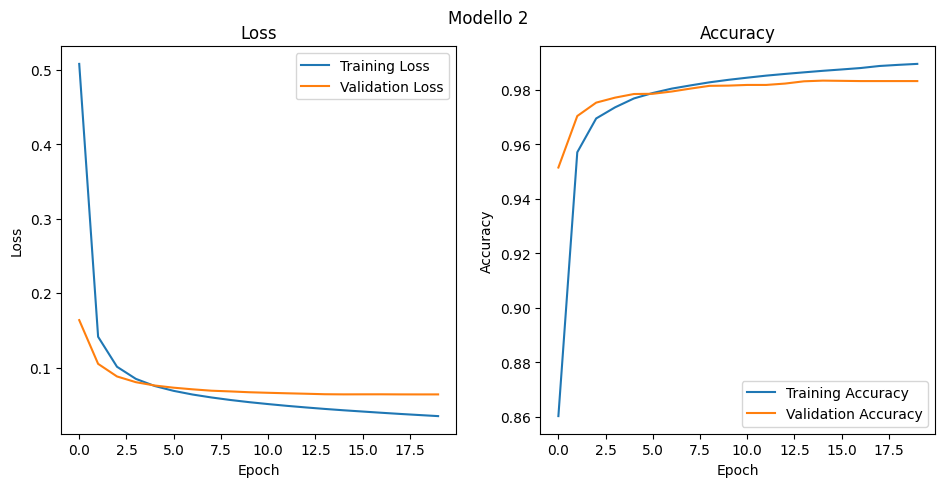

In [11]:
plot_performance(history_2, "Modello 2")

#Evaluation

In [12]:
score = model_2.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.050916437059640884
Test accuracy 0.9835000038146973


#Model 3

In [13]:
num_classes = 10
input_shape = (28,28,1)

model_3 = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(6, kernel_size=3, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.Conv2D(23, kernel_size=3, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(num_classes, activation="softmax")
])

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 12)     │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 9, 9, 23)       │         2,507 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 23)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 368)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         3,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,917 (27.02 KB)

 Trainable params: 6,917 (27.02 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
batch_size = 128
epochs = 20

model_3.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history_3 = model_3.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8720 - loss: 0.4591 - val_accuracy: 0.9570 - val_loss: 0.1457
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9621 - loss: 0.1254 - val_accuracy: 0.9710 - val_loss: 0.1008
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9714 - loss: 0.0929 - val_accuracy: 0.9753 - val_loss: 0.0833
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0778 - val_accuracy: 0.9788 - val_loss: 0.0737
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9792 - loss: 0.0681 - val_accuracy: 0.9810 - val_loss: 0.0662
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0609 - val_accuracy: 0.9822 - val_loss: 0.0609
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9833 - loss: 0.0550 - val_accuracy: 0.9838 - val_loss: 0.0577
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9850 - loss: 0.0502 - val_accuracy: 0.

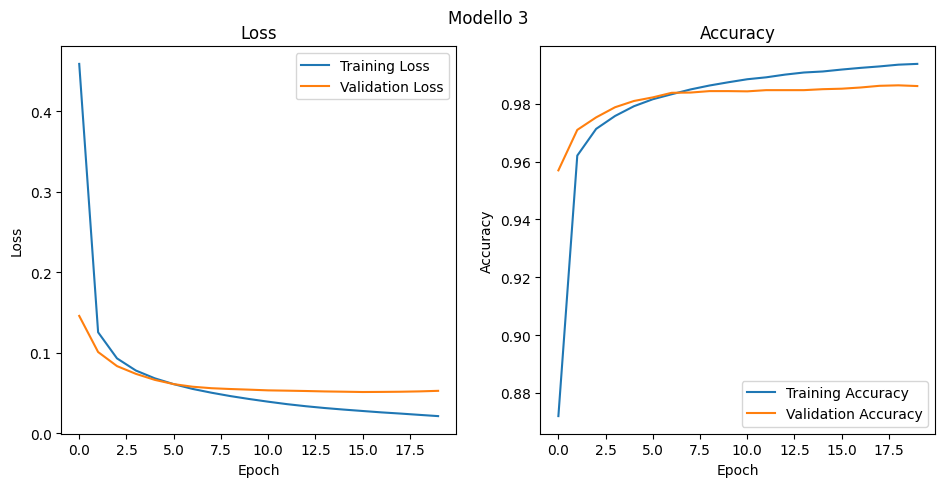

In [15]:
plot_performance(history_3, "Modello 3")

In [16]:
score = model_3.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.041240766644477844
Test accuracy 0.987500011920929


#Modello 4


In [17]:
num_classes = 10
input_shape = (28,28,1)

model_4 = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Conv2D(6, kernel_size=3, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    layers.Conv2D(12, kernel_size=3, activation="relu"),
    layers.Conv2D(23, kernel_size=3, activation="relu"),
    layers.MaxPool2D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])

model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 6)      │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 12)     │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 9, 9, 23)       │         2,507 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 23)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 368)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 368)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         3,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,917 (27.02 KB)

 Trainable params: 6,917 (27.02 KB)

 Non-trainable params: 0 (0.00 B)

##Training

In [18]:
batch_size = 128
epochs = 20

model_4.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history_4 = model_4.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8356 - loss: 0.5483 - val_accuracy: 0.9563 - val_loss: 0.1499
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9499 - loss: 0.1597 - val_accuracy: 0.9721 - val_loss: 0.0971
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9647 - loss: 0.1163 - val_accuracy: 0.9778 - val_loss: 0.0780
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9706 - loss: 0.0954 - val_accuracy: 0.9797 - val_loss: 0.0686
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9746 - loss: 0.0838 - val_accuracy: 0.9823 - val_loss: 0.0608
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9777 - loss: 0.0749 - val_accuracy: 0.9853 - val_loss: 0.0537
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9796 - loss: 0.0677 - val_accuracy: 0.9859 - val_loss: 0.0510
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9814 - loss: 0.0617 - val_accuracy: 0.

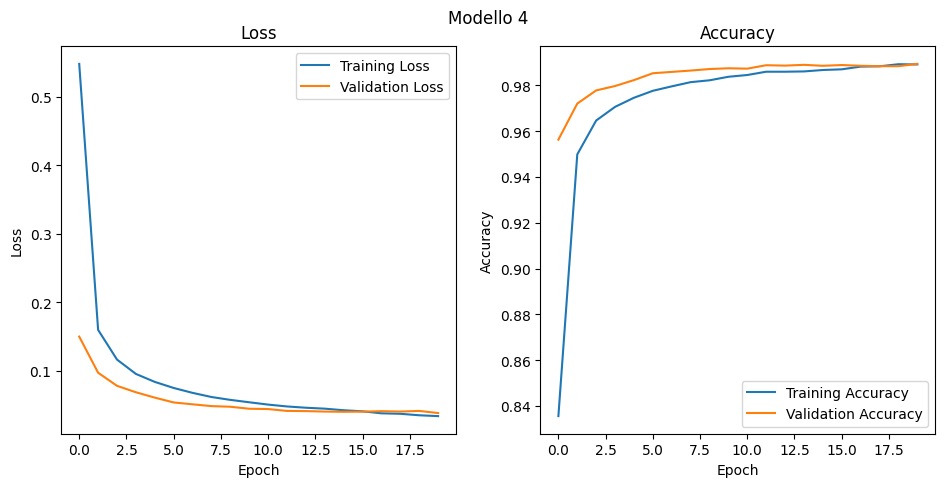

In [19]:
plot_performance(history_4, "Modello 4")

In [20]:
score = model_4.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 0.028022555634379387
Test accuracy 0.9907000064849854
